In [1]:
import os
import re
import json
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# -----------------------------------
# CONFIG
# -----------------------------------
MINISTRY_DIR = "../data/ministry_profiles"
OUTPUT_FILE = "../data/vocabulary/ministry_tfidf_vocab.json"
TOP_N = 30

In [3]:
# -----------------------------------
# 1. Text Cleaning Function
# -----------------------------------
def clean_text(text_data):
    """
    - Lowercase
    - Remove numbers
    - Keep only alphabets
    - Remove extra spaces
    """

    text_data = text_data.lower()

    # Remove numbers
    text_data = re.sub(r'\d+', ' ', text_data)

    # Keep only alphabets
    text_data = re.sub(r'[^a-z\s]', ' ', text_data)

    # Remove extra spaces
    text_data = re.sub(r'\s+', ' ', text_data).strip()

    return text_data


# -----------------------------------
# 2. Load Ministry Text Files
# -----------------------------------
def load_ministry_files(directory):
    ministries = {}

    for file in os.listdir(directory):
        if file.endswith(".txt"):
            file_path = os.path.join(directory, file)

            with open(file_path, "r", encoding="utf-8") as f:
                text_data = f.read()

            cleaned = clean_text(text_data)

            ministry_name = file.replace(".txt", "")
            ministries[ministry_name] = cleaned

    return ministries


# -----------------------------------
# 3. TF-IDF Keyword Extraction
# -----------------------------------
def extract_tfidf_keywords(ministries, top_n=25):
    docs = list(ministries.values())
    names = list(ministries.keys())
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_df=0.85,
        min_df=3,
        ngram_range=(1, 2),  # unigrams + bigrams
        token_pattern=r'\b[a-z]{3,}\b'  # only alphabet words >=3 letters
    )

    tfidf_matrix = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()

    ministry_keywords = {}

    for idx, name in enumerate(names):
        row = tfidf_matrix[idx].toarray().flatten()
        top_indices = row.argsort()[-top_n:][::-1]

        keywords = [feature_names[i] for i in top_indices]
        ministry_keywords[name] = keywords

    return ministry_keywords


# -----------------------------------
# 4. Save Vocabulary File
# -----------------------------------
def save_vocab(vocab_dict, output_file):
    Path(os.path.dirname(output_file)).mkdir(parents=True, exist_ok=True)

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(vocab_dict, f, indent=4)

    print(f"Vocabulary saved to: {output_file}")

In [4]:
print("Loading ministry files...")
ministries = load_ministry_files(MINISTRY_DIR)
print(f"Total ministries loaded: {len(ministries)}")

print("Extracting TF-IDF keywords...")
ministry_keywords = extract_tfidf_keywords(ministries, TOP_N)

print("Saving vocabulary...")
save_vocab(ministry_keywords, OUTPUT_FILE)

Loading ministry files...
Total ministries loaded: 53
Extracting TF-IDF keywords...
Saving vocabulary...
Vocabulary saved to: ../data/vocabulary/ministry_tfidf_vocab.json


In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

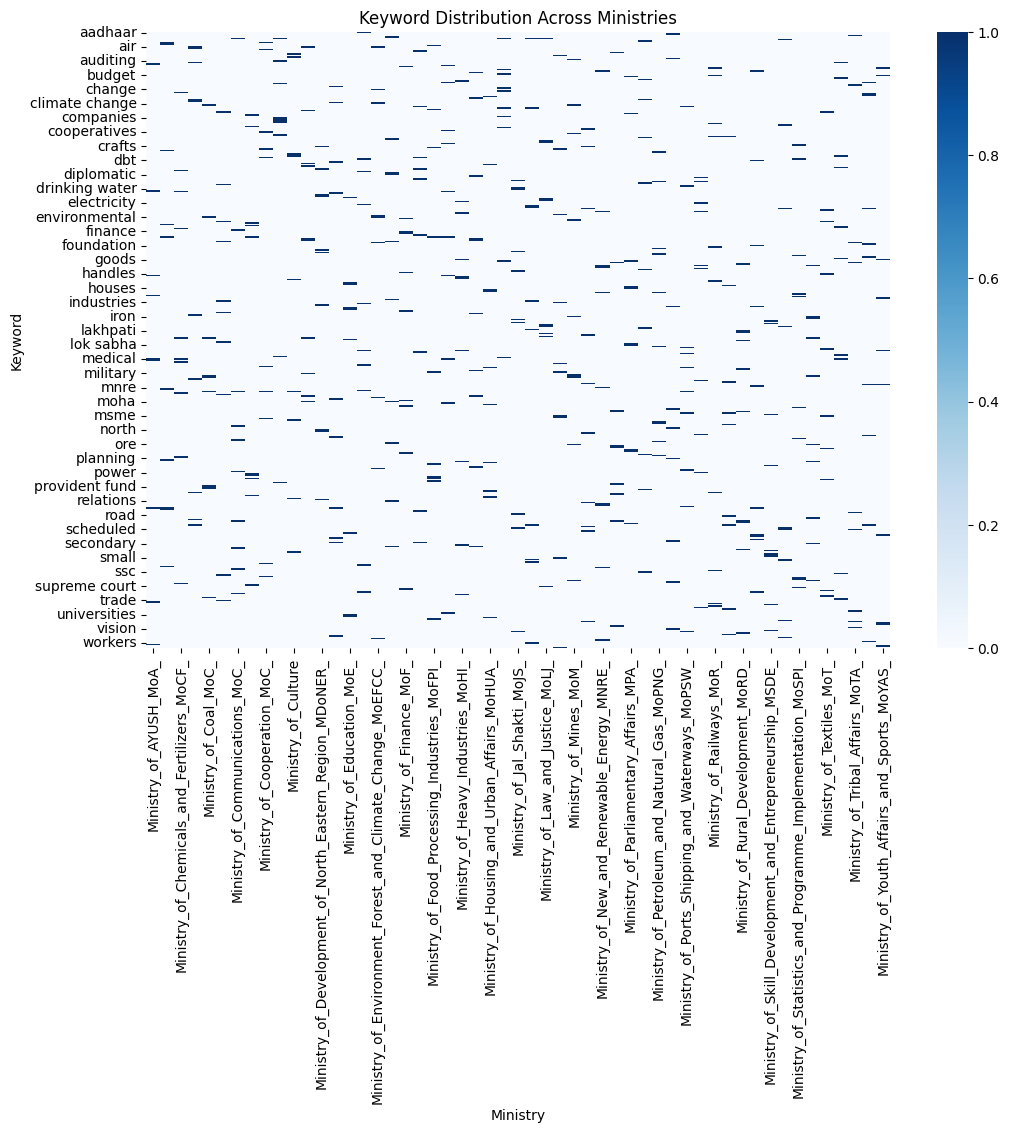

In [6]:
# build dataframe
data = []

for ministry, words in ministry_keywords.items():
    for w in words[:10]:
        data.append((ministry, w, 1))

df = pd.DataFrame(data, columns=["Ministry","Keyword","Value"])

pivot = df.pivot(index="Keyword", columns="Ministry", values="Value").fillna(0)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="Blues")

plt.title("Keyword Distribution Across Ministries")
plt.show()

In [13]:
from collections import Counter

counter = Counter()

for ministry, words in ministry_keywords.items():
    counter.update(words)

# get top words
top_words = counter.most_common(30)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

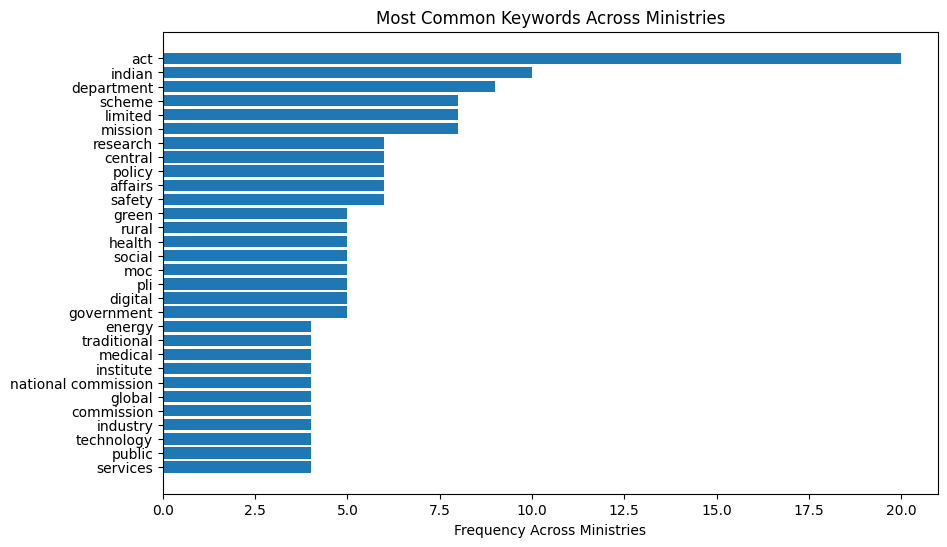

In [14]:
plt.figure(figsize=(10,6))

plt.barh(words, counts)

plt.xlabel("Frequency Across Ministries")
plt.title("Most Common Keywords Across Ministries")

plt.gca().invert_yaxis()

plt.show()

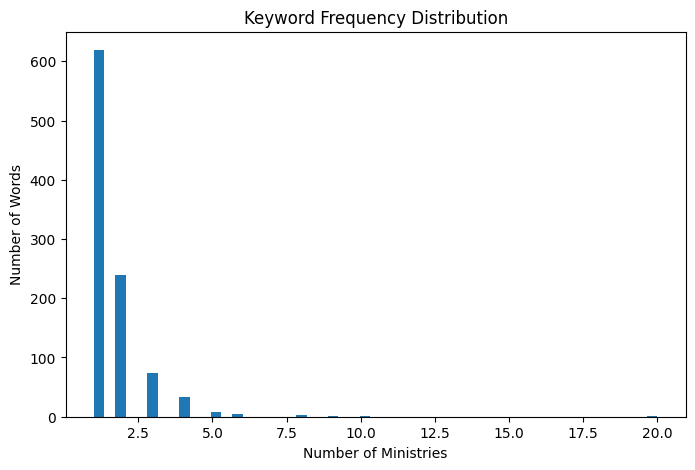

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(counter.values(), bins=len(ministry_keywords))

plt.xlabel("Number of Ministries")
plt.ylabel("Number of Words")

plt.title("Keyword Frequency Distribution")

plt.show()

# words appearing in 1 ministry  -> good (specific)
# words appearing in many ministries -> generic